In [9]:
import numpy as np
from matplotlib import pyplot as plt
import scipy

In [639]:
%run lib.ipynb

# Ex. 1

Exercise 1: Convergence Order Verification
-

For any ODE with a known exact solution (e.g. $y^{\prime}=-y, y(0)=1$, exact: $y=e^{-t}$ ), a method of order $p$ should satisfy $\left|y\left(t_f\right)-y_N\right| \propto h^p$.

(a) For the test problem $y^{\prime}=-y$ integrated to $t_f=1$, compute the global error for each of the following methods at $h=0.2,0.1,0.05,0.025,0.0125$ : forward Euler, backward Euler, explicit midpoint, Heun (predictor-corrector), implicit midpoint, RK4, AB2, AB4, AM1 (trapezoidal), BDF2 (How do you manage to start a multistep method?).

(b) Plot $\log _{10} \mid$ error $\mid$ vs. $\log _{10} h$ for all methods on the same graph. Measure the slopes by linear regression and compare with the theoretical orders.

(c) Identify any methods where the measured order deviates from the theoretical one and explain possible causes (startup errors for multistep methods, round-off at very small $h$, etc.).

In [590]:
def f_prime(t,y,args):
    return -y

In [35]:
integrate?

Signature: integrate(df_dt, t_range, IC, h, args=None, method=None)
Docstring: <no docstring>
File:      /tmp/ipykernel_60100/1072355963.py
Type:      function

In [591]:
h = 0.01
tf = 1

t_span = (0,tf)
y0 = [1]



In [592]:
tee,yee = integrate(f_prime,t_span,y0,h,method=euler_explicit)
tei,yei = integrate(f_prime,t_span,y0,h,method=euler_implicit)
tme,yme = integrate(f_prime,t_span,y0,h,method=midpoint_explicit)
tmi,ymi = integrate(f_prime,t_span,y0,h,method=midpoint_implicit)
tpc,ypc = integrate(f_prime,t_span,y0,h,method=predictor_corrector)

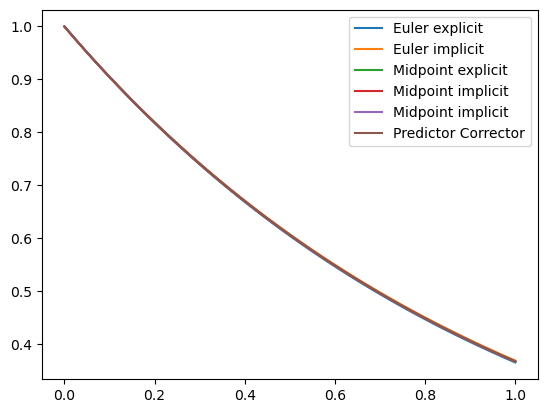

In [593]:
plt.plot(tee,yee[0], label='Euler explicit')
plt.plot(tei,yei[0], label='Euler implicit')
plt.plot(tme,yme[0], label='Midpoint explicit')
plt.plot(tmi,ymi[0], label='Midpoint implicit')
plt.plot(tmi,ymi[0], label='Midpoint implicit')
plt.plot(tpc,ypc[0], label='Predictor Corrector')

plt.legend()

EULER EXPLICIT
-

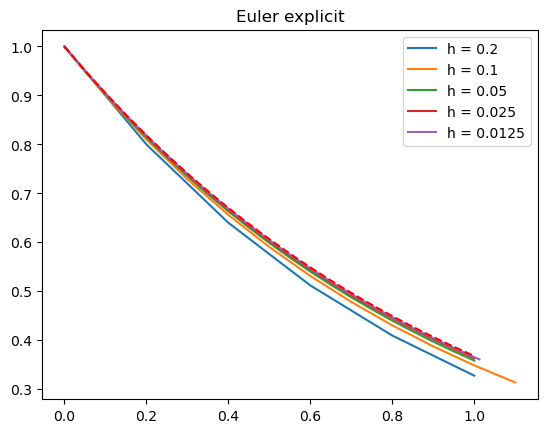

In [594]:
hs = [0.2,0.10,0.05,0.025,0.0125]
for h in hs:
    tee,yee = integrate(f_prime,t_span,y0,h,method=euler_explicit)
    plt.plot(tee,yee[0], label='h = '+str(h))
plt.legend()
plt.title('Euler explicit')
x=np.linspace(0,1)
plt.plot(x,np.exp(-x), linestyle='--',c='r')

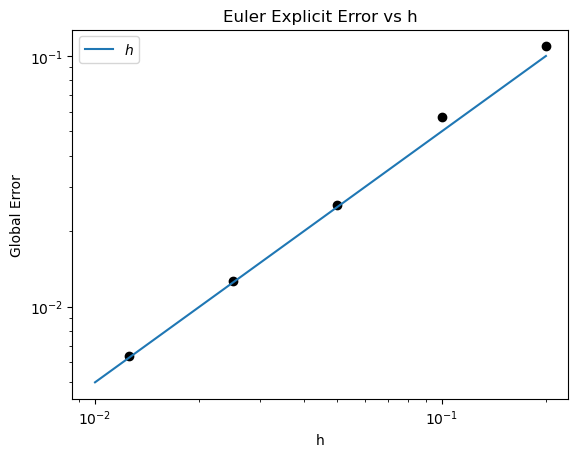

In [595]:
tEE, yEE = [], []
for h in hs:
    tee,yee = integrate(f_prime,t_span,y0,h,method=euler_explicit)
    plt.scatter(h,abs(yee[0][-1]-np.exp(-tee[-1]))/np.exp(-tee[-1]), color='k')
    tEE, yEE = np.append(tEE, tee), np.append(yEE, yee)
plt.title('Euler Explicit Error vs h')
plt.yscale('log')
plt.xscale('log')
x = np.linspace(0.01,0.2)
plt.plot(x,x/2,label=f'$h$')
plt.xlabel('h')
plt.ylabel('Global Error')
plt.legend()

EULER IMPLICIT
-

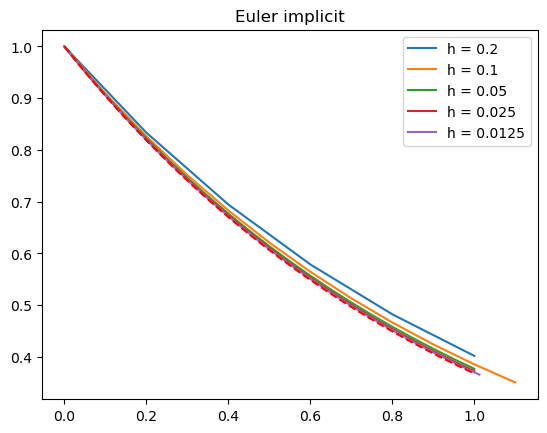

In [596]:
for h in hs:
    tei,yei = integrate(f_prime,t_span,y0,h,method=euler_implicit)
    plt.plot(tei,yei[0], label='h = '+str(h))
plt.legend()
plt.title('Euler implicit')
x=np.linspace(0,1)
plt.plot(x,np.exp(-x), linestyle='--',c='r')

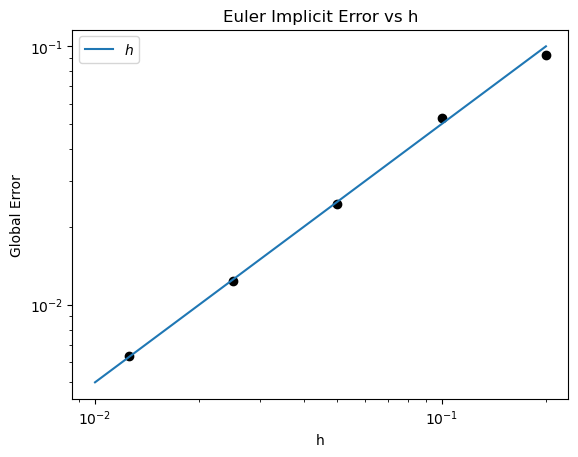

In [597]:
tEI, yEI, eEI = [], [], []
for h in hs:
    tei,yei = integrate(f_prime,t_span,y0,h,method=euler_implicit)
    eei = (yei[0][-1]-np.exp(-tei[-1]))/np.exp(-tei[-1])
    plt.scatter(h, eei, color='k')
    tEI, yEI, eEI = np.append(tEI, tei), np.append(yEI, yei), np.append(eEI, eei)

plt.title('Euler Implicit Error vs h')
plt.yscale('log')
plt.xscale('log')
x = np.linspace(0.01,0.2)
plt.plot(x,x/2,label=f'$h$')
plt.xlabel('h')
plt.ylabel('Global Error')
plt.legend()

MIDPOINT EXPLICIT
-

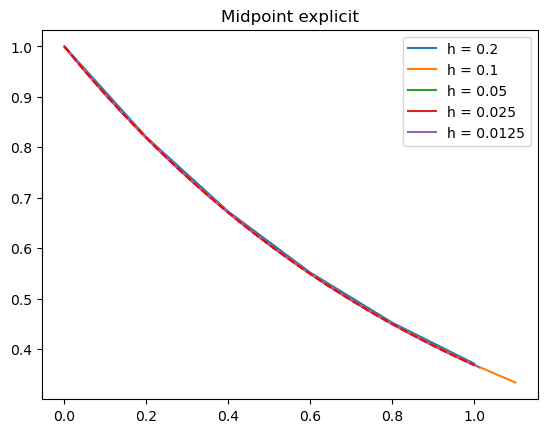

In [598]:
for h in hs:
    tme,yme = integrate(f_prime,t_span,y0,h,method=midpoint_explicit)
    plt.plot(tme,yme[0], label='h = '+str(h))
plt.legend()
plt.title('Midpoint explicit')
x=np.linspace(0,1)
plt.plot(x,np.exp(-x), linestyle='--',c='r')

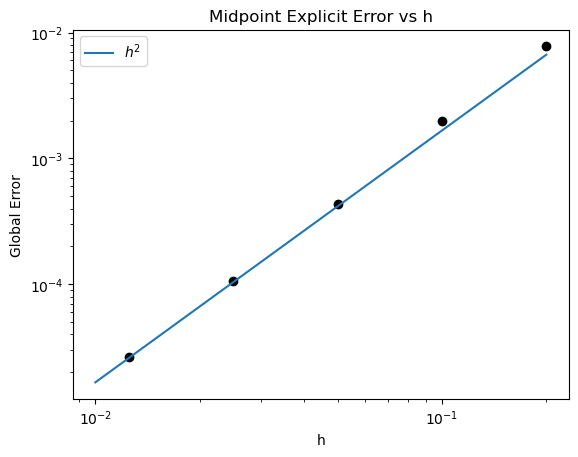

In [599]:
tME, yME = [], []
for h in hs:
    tme,yme = integrate(f_prime,t_span,y0,h,method=midpoint_explicit)
    plt.scatter(h,(yme[0][-1]-np.exp(-tme[-1]))/np.exp(-tme[-1]), color='k')
    tME, yME = np.append(tME, tme), np.append(yME, yme)
plt.title('Midpoint Explicit Error vs h')
plt.yscale('log')
plt.xscale('log')
x = np.linspace(0.01,0.2)
plt.plot(x,x**2/6,label=f'$h^2$')
plt.xlabel('h')
plt.ylabel('Global Error')
plt.legend()

MIDPOINT IMPLICIT
-

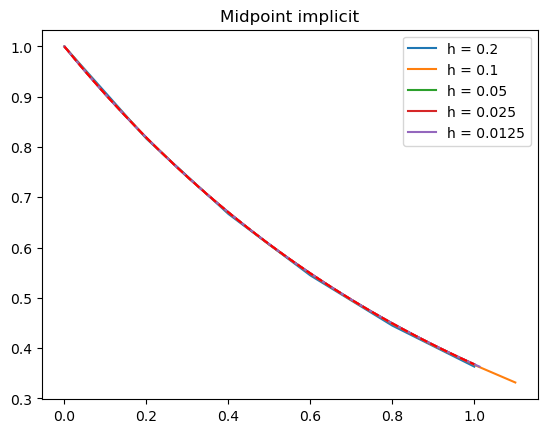

In [600]:
for h in hs:
    tmi,ymi = integrate(f_prime,t_span,y0,h,method=midpoint_implicit)
    plt.plot(tmi,ymi[0], label='h = '+str(h))
plt.legend()
plt.title('Midpoint implicit')
x=np.linspace(0,1)
plt.plot(x,np.exp(-x), linestyle='--',c='r')

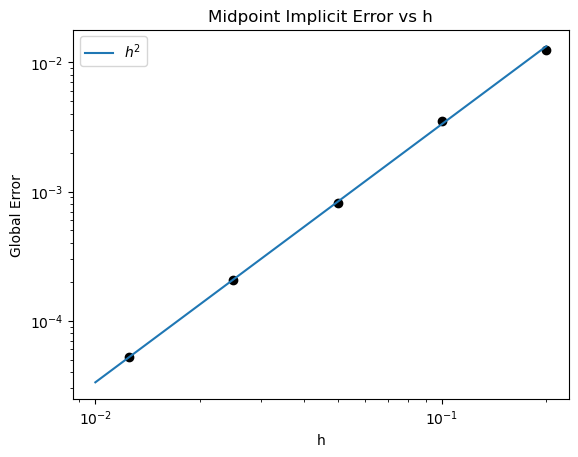

In [605]:
tMI, yMI, eMI = [], [], []
for h in hs:
    tmi,ymi = integrate(f_prime,t_span,y0,h,method=midpoint_implicit)
    emi = abs(ymi[0][-1]-np.exp(-tmi[-1]))/np.exp(-tmi[-1])
    plt.scatter(h, emi, color='k')
    tMI, yMI, eMI = np.append(tMI, tmi), np.append(yMI, ymi), np.append(eMI, emi)
plt.title('Midpoint Implicit Error vs h')
plt.yscale('log')
plt.xscale('log')
x = np.linspace(0.01,0.2)
plt.plot(x,x**2/3,label=f'$h^2$')
plt.xlabel('h')
plt.ylabel('Global Error')
plt.legend()

PREDICTOR CORRECTOR
-

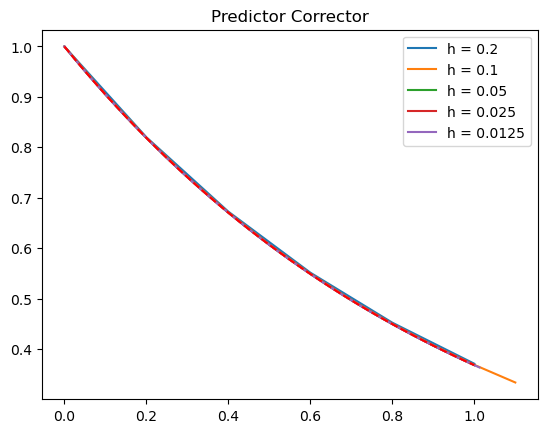

In [606]:
for h in hs:
    tpc,ypc = integrate(f_prime,t_span,y0,h,method=predictor_corrector)
    plt.plot(tpc,ypc[0], label='h = '+str(h))
plt.legend()
plt.title('Predictor Corrector')
x=np.linspace(0,1)
plt.plot(x,np.exp(-x), linestyle='--',c='r')

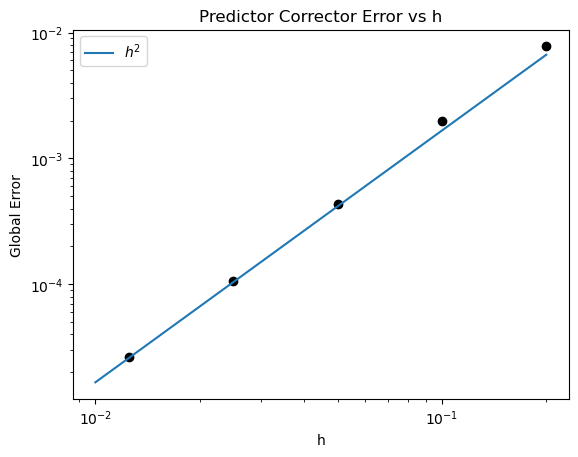

In [276]:
tPC, yPC, ePC = [], [], []
for h in hs:
    tpc,ypc = integrate(f_prime,t_span,y0,h,method=predictor_corrector)
    epc = (ypc[0][-1]-np.exp(-tpc[-1]))/np.exp(-tpc[-1])
    plt.scatter(h, epc, color='k')
    tPC, yPC, ePC = np.append(tPC, tpc), np.append(yPC, ypc), np.append(ePC, epc)

plt.title('Predictor Corrector Error vs h')
plt.yscale('log')
plt.xscale('log')
x = np.linspace(0.01,0.2)
plt.plot(x,x**2/6,label=f'$h^2$')
plt.xlabel('h')
plt.ylabel('Global Error')
plt.legend()

RUNGE KUTTA 4
-

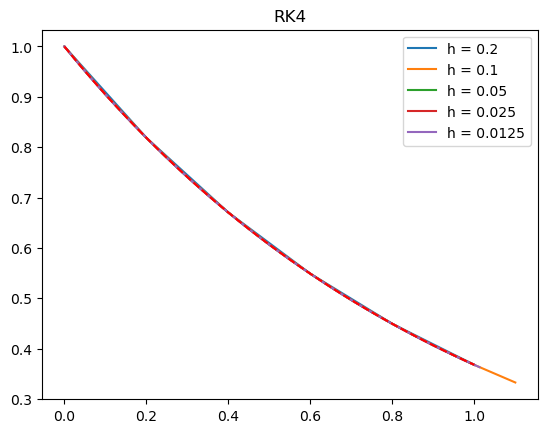

In [106]:
for h in hs:
    trk,yrk = integrate(f_prime,t_span,y0,h,method=RK4)
    plt.plot(trk,yrk[0], label='h = '+str(h))
plt.legend()
plt.title('RK4')
x=np.linspace(0,1)
plt.plot(x,np.exp(-x), linestyle='--',c='r')

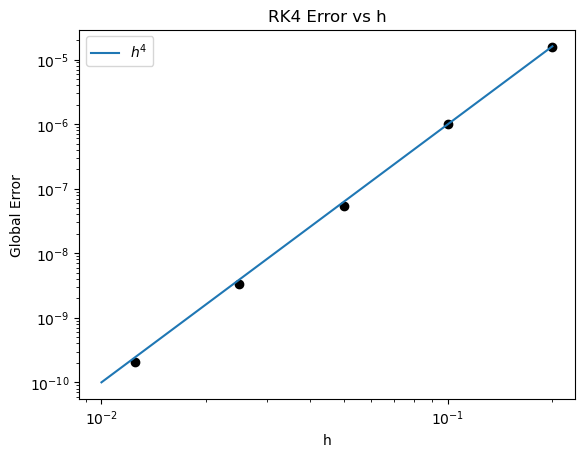

In [267]:
tRK, yRK, eRK, hss = [], [], [], []
for h in hs:
    trk,yrk = integrate(f_prime,t_span,y0,h,method=RK4)
    erk = (yrk[0][-1]-np.exp(-trk[-1]))/np.exp(-trk[-1])
    plt.scatter(h,erk, color='k')
    tRK, yRK, eRK, hss = np.append(tRK, trk), np.append(yRK, yrk), np.append(eRK, erk), np.append(hss,h)
plt.title('RK4 Error vs h')
plt.yscale('log')
plt.xscale('log')
x = np.linspace(0.01,0.2)
plt.plot(x,x**4/100,label=f'$h^4$')
plt.xlabel('h')
plt.ylabel('Global Error')
plt.legend()

COMPARISON
-

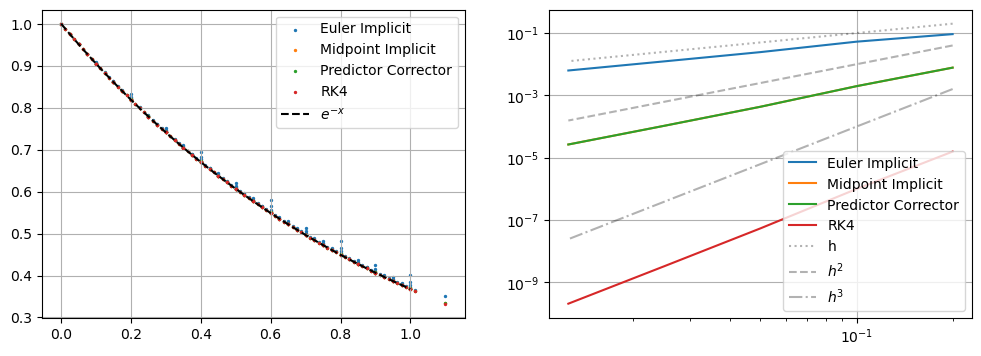

In [299]:
fig, ax = plt.subplots(1,2, figsize=(12,4))


ax[0].scatter(tEI,yEI,s=2, label = 'Euler Implicit')
ax[0].scatter(tMI,yMI,s=2, label = 'Midpoint Implicit')
ax[0].scatter(tPC,yPC,s=2, label = 'Predictor Corrector')
ax[0].scatter(tRK,yRK,s=2, label = 'RK4')

x = np.linspace(0,1)
ax[0].plot(x,np.exp(-x), linestyle='--', c='k', label = r'$e^{-x}$')



ax[1].plot(hss,eEI, label = 'Euler Implicit')
ax[1].plot(hss,eMI, label = 'Midpoint Implicit')
ax[1].plot(hss,ePC, label = 'Predictor Corrector')
ax[1].plot(hss,eRK, label = 'RK4')

ax[1].plot(hss,hss, label = 'h', linestyle=':', alpha=0.3, c='k')
ax[1].plot(hss,hss**2, label = r'$h^2$', linestyle='--', alpha=0.3, c='k')
ax[1].plot(hss,hss**4, label = r'$h^3$', linestyle='-.', alpha=0.3, c='k')



ax[1].set_yscale('log')
ax[1].set_xscale('log')
ax[1].legend()
ax[0].legend()
ax[0].grid()
ax[1].grid()

In [ ]:
#per i metodi multistep è importante sapere che vanno usati altri metodi per otetnere fn-1 e fn ecc.

ADAMS-BASHFORD 2
-

In [300]:
h = 0.01
tf = 1

t_span = (0+h,tf)
#se la funzione è definita anche a tempi prima della solita condizione inziale allora posso usare nel range 0,1 y0 = [np.exp(h)]
y0 =[1]
y_n = RK4(0,1,f_prime,h)

y_n = np.exp(-h)

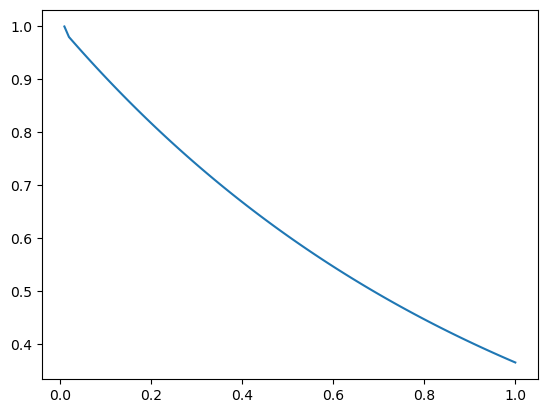

In [301]:
tab2,yab2 = integrate_multi(f_prime,t_span,y0,h,y_n,method=AB2_explicit2)
plt.plot(tab2,yab2[0])

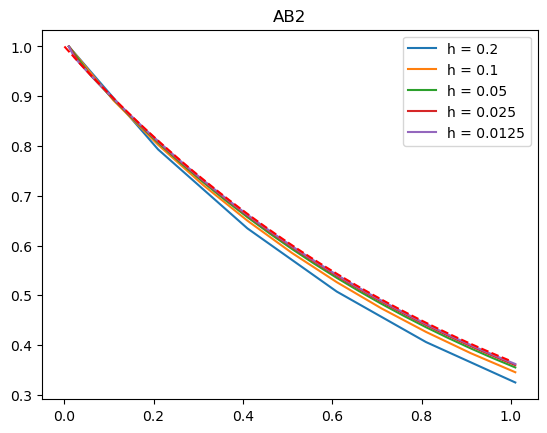

In [302]:
for h in hs:
    tab2,yab2 = integrate_multi(f_prime,t_span,y0,h,y_n,method=AB2_explicit2)
    plt.plot(tab2,yab2[0], label='h = '+str(h))
plt.legend()
plt.title('AB2')
x=np.linspace(0,1)
plt.plot(x,np.exp(-x), linestyle='--',c='r')

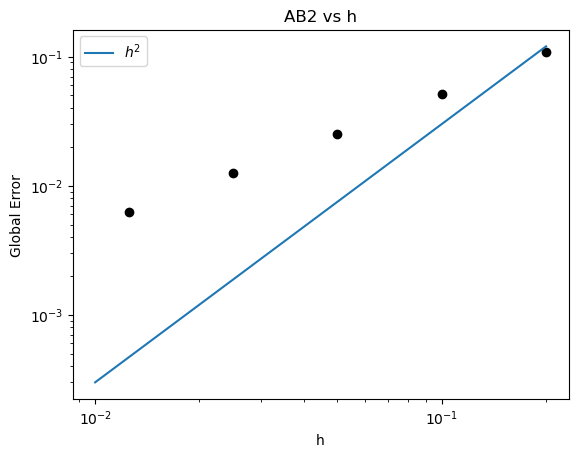

In [303]:
for h in hs:
    tab2,yab2 = integrate_multi(f_prime,t_span,y0,h,y_n,method=AB2_explicit2)
    plt.scatter(h,abs(yab2[0][-1]-np.exp(-tab2[-1]))/np.exp(-tab2[-1]), color='k')
plt.title('AB2 vs h')
plt.yscale('log')
plt.xscale('log')
x = np.linspace(0.01,0.2)
plt.plot(x,x**2*3,label=f'$h^2$')
plt.xlabel('h')
plt.ylabel('Global Error')
plt.legend()

In [304]:
# da rifare perché dovrebbe venire di ordine due :(

# Ex. 2

Exercise 2: Stiff System - Explicit vs. Implicit
-

Consider the linear system

$$
\binom{u^{\prime}}{v^{\prime}}=\underbrace{\left(\begin{array}{cc}
998 & 1998  \tag{1}\\
-999 & -1999
\end{array}\right)}_A\binom{u}{v}, \quad\binom{u(0)}{v(0)}=\binom{1}{0} .
$$

(a) (Optional) Compute analytical solution. Compute the eigenvalues and eigenvectors of $A$ (Hint: use transformation $u=2 y-z, v=-y+z$ ). Show that $\lambda_1=-1$ and $\lambda_2=-1000$. Write the exact solution:

$$
u(t)=2 e^{-t}-e^{-1000 t}, \quad v(t)=-e^{-t}+e^{-1000 t}
$$


Identify the fast transient $\left(e^{-1000 t}\right.$, decays by $t \approx 0.01$ ) and the slow dynamics ( $e^{-t}$, persists until $t \sim 5$ ).

(b) Stiffness analysis. Compute the stiffness ratio $S=\left|\lambda_{\text {max }}\right| /\left|\lambda_{\text {min }}\right|$. For each of the four methods below, compute the maximum stable step size $h_{\text {stab }}$ and compare it with the step size $h_{\text {acc }}$ needed to follow the slow solution to $1 \%$ relative accuracy. Explain why this system is stiff (Remind: $h_{\text {stab }} \lesssim \frac{c}{\lambda_{\text {max }}}$ ).

(c) Forward Euler (explicit, order 1). Implement and integrate from $t=0$ to $t=5$.

(i) Use $h=0.003$ (above the stability limit). Observe the blow-up and explain it using the eigenvalues and the stability region from Exercise 1.
(ii) Use $h=0.001$ (below the stability limit). Confirm the solution is now stable. How many steps are needed? Compare with the number of steps that would suffice for accuracy if stability were not a constraint.

(d) Explicit midpoint (explicit, order 2). Repeat the experiment with $h=0.003$ and $h=$ 0.001 . Is the stability limit significantly different from forward Euler? Does the higher order help with the stiffness problem?

(e) Backward Euler (implicit, order 1). Implement using Newton iteration (or, since the system is linear, direct matrix inversion) at each step. Integrate with $h=0.1$ ( $200 \times$ the explicit Euler stability limit).

In [564]:
S = 1000/1 #stiffness del problema: |lambda max| / |lambda min|

In [607]:
def u_prime(u,v):
    return 998*u + 1998*v
def v_prime(u,v):
    return -999*u - 1999*v  
def f_prime(t,y,args):
    u, v = y
    return np.array([u_prime(u,v), v_prime(u,v)])

In [608]:
tf = 5
t_span = (0,tf)
y0 = np.array([1,0])

In [609]:
def hacc(tau,erel,p):
    return tau*erel**(1/p)

Per calcolare max hstable bisogna riscrivere per ciascun metodo $y_{n+1}$ = R(z) * $y_n$, con z = $\lambda$ * h 

(Questo vale per problemi in cui vale y' = - $\lambda$ * y)

Imponendo poi |R(z)| <= 1 trovo $max(h_{stab})$ considerando tra le due $\lambda_{max}$ = -1000 (che è quella che dà problemi)

$h_{accuracy} ∼ \tau · \epsilon ^ {1/p} _{rel}$
 

## (c): EULER EXPLICIT

/tmp/ipykernel_60100/2989824735.py:17: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


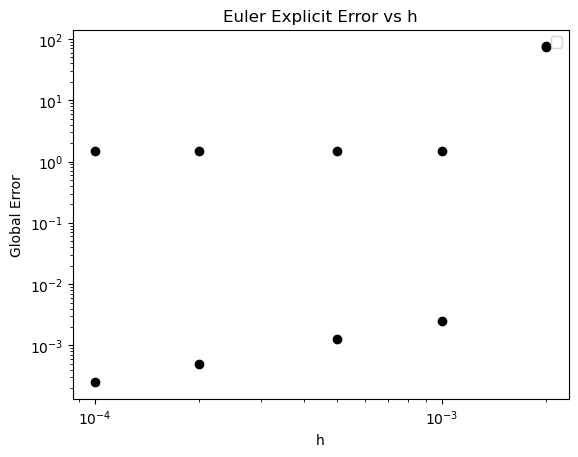

In [472]:
hs = [ 0.002, 0.001, 0.0005, 0.0002, 0.0001]

tEE, uEE, vEE = [], [], []
for h in hs:
    tee,yee = integrate(f_prime,t_span,y0,h,method=euler_explicit)
    plt.scatter(h,abs(yee[0][-1]-(2*np.exp(-tee[-1])-np.exp(-1000*tee[-1])))/(2*np.exp(-tee[-1])-np.exp(-1000*tee[-1])), color='k')
    plt.scatter(h,abs(yee[1][-1]-(2*np.exp(-tee[-1])-np.exp(-1000*tee[-1])))/(2*np.exp(-tee[-1])-np.exp(-1000*tee[-1])), color='k')
    tEE, uEE, vEE = np.append(tEE, tee), np.append(yEE, yee[0]), np.append(yEE, yee[1])

#plt.vlines(0.002, 0,1e120, linestyle='--', label=r'$max(h_{stab})$ = 0.002')
plt.title('Euler Explicit Error vs h')
plt.yscale('log')
plt.xscale('log')
x = np.linspace(0.01,0.2)
plt.xlabel('h')
plt.ylabel('Global Error')
plt.legend()

Nel metodo di Eulero Esplicito:

R(z) = 1 + z = 1 + $\lambda$ h

| 1 - 1000 * h | $\leq$ 1 -> 1000 * h $\leq$ 2

-> $max(h_{stab})$ = 0.002

Per calcolare $h_{accuracy}$ $\tau$ = 5 e p ordine del metodo: per EE 1

In [402]:
erel = 0.01
tau = 5
p = 1
print('h_acc = '+str(hacc(tau,erel,p))+ ' -> the problem is STIFF')

h_acc = 0.05 -> the problem is STIFF


$h = 0.003$

/tmp/ipykernel_60100/2881422949.py:2: RuntimeWarning: overflow encountered in scalar multiply
  return 998*u + 1998*v
/tmp/ipykernel_60100/2881422949.py:4: RuntimeWarning: overflow encountered in scalar multiply
  return -999*u - 1999*v
/tmp/ipykernel_60100/2881422949.py:2: RuntimeWarning: invalid value encountered in scalar add
  return 998*u + 1998*v
/tmp/ipykernel_60100/2881422949.py:4: RuntimeWarning: invalid value encountered in scalar subtract
  return -999*u - 1999*v


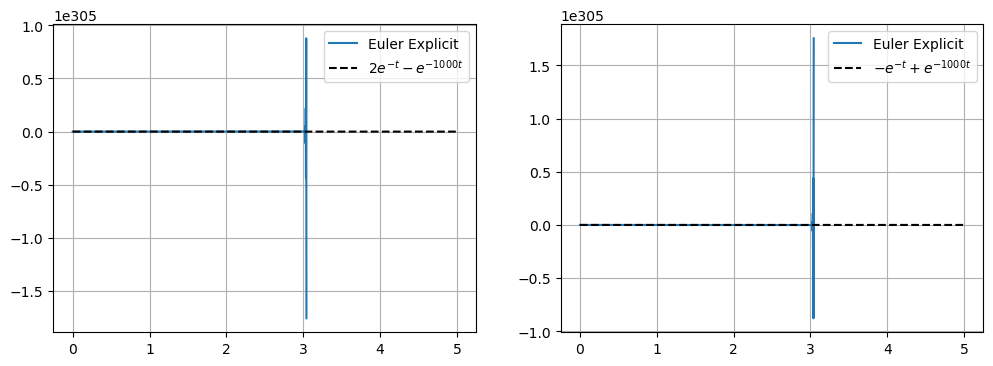

In [477]:
h = 0.003
tee,yee = integrate(f_prime,t_span,y0,h,method=euler_explicit)

fig, ax = plt.subplots(1,2, figsize=(12,4))

x = np.linspace(min(tee),max(tee), 10000)

ax[0].plot(tee,yee[0], label = 'Euler Explicit')
ax[0].plot(x,2*np.exp(-x)-np.exp(-1000*x), linestyle='--', c='k', label = r'$2e^{-t}-e^{-1000t}$')

ax[1].plot(tee,yee[1], label = 'Euler Explicit')
ax[1].plot(x,-np.exp(-x)+np.exp(-1000*x), linestyle='--', c='k', label = r'$-e^{-t}+e^{-1000t}$')

#ax[0].set_xlim(0,0.9)
#ax[1].set_xlim(0,0.9)

ax[1].legend()
ax[0].legend()
ax[0].grid()
ax[1].grid()

$h = 0.001$

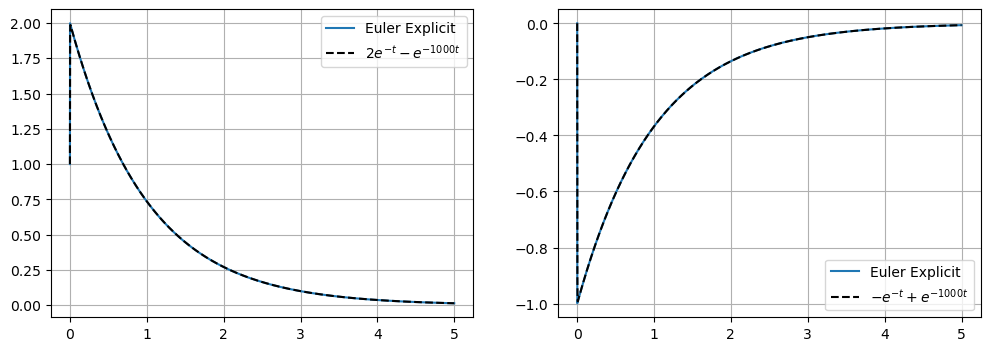

In [408]:
h = 0.001
tee,yee = integrate(f_prime,t_span,y0,h,method=euler_explicit)

fig, ax = plt.subplots(1,2, figsize=(12,4))

x = np.linspace(min(tee),max(tee), 10000)

ax[0].plot(tee,yee[0], label = 'Euler Explicit')
ax[0].plot(x,2*np.exp(-x)-np.exp(-1000*x), linestyle='--', c='k', label = r'$2e^{-t}-e^{-1000t}$')

ax[1].plot(tee,yee[1], label = 'Euler Explicit')
ax[1].plot(x,-np.exp(-x)+np.exp(-1000*x), linestyle='--', c='k', label = r'$-e^{-t}+e^{-1000t}$')

#ax[0].set_xlim(0,0.9)
#ax[1].set_xlim(0,0.9)

ax[1].legend()
ax[0].legend()
ax[0].grid()
ax[1].grid()

How many steps are needed? 

$\Delta t = \frac{2}{|\lambda|}$

$N \geq \frac{T \cdot |\lambda|}{2}$

In [405]:
N = tf*1000/2
print('The minimum number of steps is: '+ str(N)) #checkkk

The minimum number of steps is: 2500.0


## (d): MIDPOINT EXPLICIT

Nel metodo di Eulero Esplicito:

R(z) = 1 + z + $z^2$ = 1 + $\lambda$ h + $\lambda^2$ $h^2$

| 1 - 1000 * h +1e6 h$^2$ | $\leq$ 1 -> 

-> $max(h_{stab})$ = 0.002

Il passo per la stabilità è lo stesso di Eulero esplicito

/tmp/ipykernel_60100/2881422949.py:2: RuntimeWarning: overflow encountered in scalar multiply
  return 998*u + 1998*v
/tmp/ipykernel_60100/2881422949.py:2: RuntimeWarning: invalid value encountered in scalar add
  return 998*u + 1998*v
/tmp/ipykernel_60100/2881422949.py:4: RuntimeWarning: overflow encountered in scalar multiply
  return -999*u - 1999*v
/tmp/ipykernel_60100/2881422949.py:4: RuntimeWarning: invalid value encountered in scalar subtract
  return -999*u - 1999*v


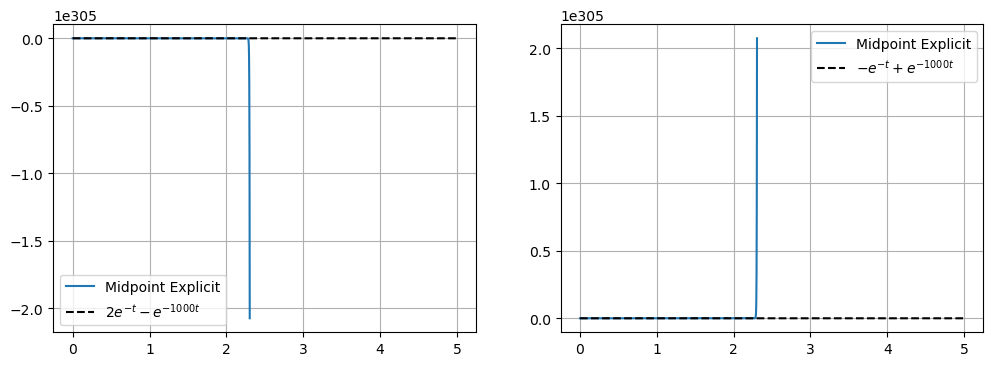

In [486]:
h = 0.003
tee,yee = integrate(f_prime,t_span,y0,h,method=midpoint_explicit)

fig, ax = plt.subplots(1,2, figsize=(12,4))

x = np.linspace(min(tee),max(tee), 10000)

ax[0].plot(tee,yee[0], label = 'Midpoint Explicit')
ax[0].plot(x,2*np.exp(-x)-np.exp(-1000*x), linestyle='--', c='k', label = r'$2e^{-t}-e^{-1000t}$')

ax[1].plot(tee,yee[1], label = 'Midpoint Explicit')
ax[1].plot(x,-np.exp(-x)+np.exp(-1000*x), linestyle='--', c='k', label = r'$-e^{-t}+e^{-1000t}$')

#ax[0].set_xlim(0,0.9)
#ax[1].set_xlim(0,0.9)

ax[1].legend()
ax[0].legend()
ax[0].grid()
ax[1].grid()

$h = 0.001$

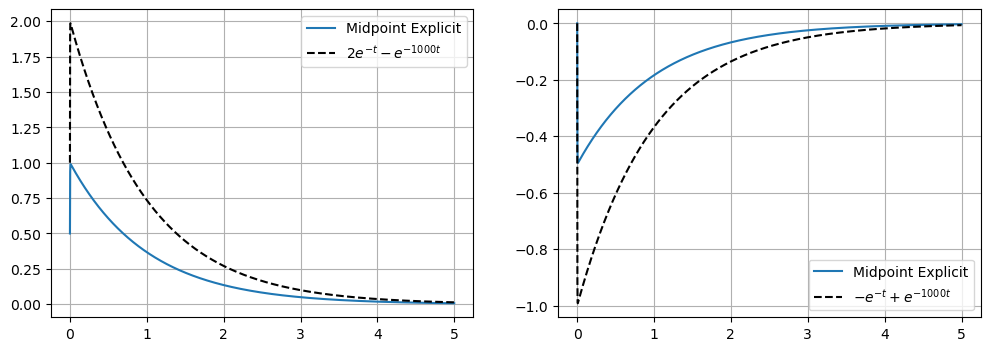

In [487]:
h = 0.001
tee,yee = integrate(f_prime,t_span,y0,h,method=midpoint_explicit)

fig, ax = plt.subplots(1,2, figsize=(12,4))

x = np.linspace(min(tee),max(tee), 10000)

ax[0].plot(tee,yee[0], label = 'Midpoint Explicit')
ax[0].plot(x,2*np.exp(-x)-np.exp(-1000*x), linestyle='--', c='k', label = r'$2e^{-t}-e^{-1000t}$')

ax[1].plot(tee,yee[1], label = 'Midpoint Explicit')
ax[1].plot(x,-np.exp(-x)+np.exp(-1000*x), linestyle='--', c='k', label = r'$-e^{-t}+e^{-1000t}$')

#ax[0].set_xlim(0,0.9)
#ax[1].set_xlim(0,0.9)

ax[1].legend()
ax[0].legend()
ax[0].grid()
ax[1].grid()

In [429]:
erel = 0.01
tau = 5 #temposcala lento
p = 2
print('h_acc = '+str(hacc(tau,erel,p))+ ' -> the problem is STIFF') #non è migliorato! Anzi!

h_acc = 0.5 -> the problem is STIFF


## (e): EULER IMPLICIT

Nel metodo Euler Implicito:

-> Sempre stabile

In [568]:
h = 0.01
tei,yei = integrate(f_prime,t_span,y0,h,method=euler_implicit)
np.shape(yee)

(2, 10001)

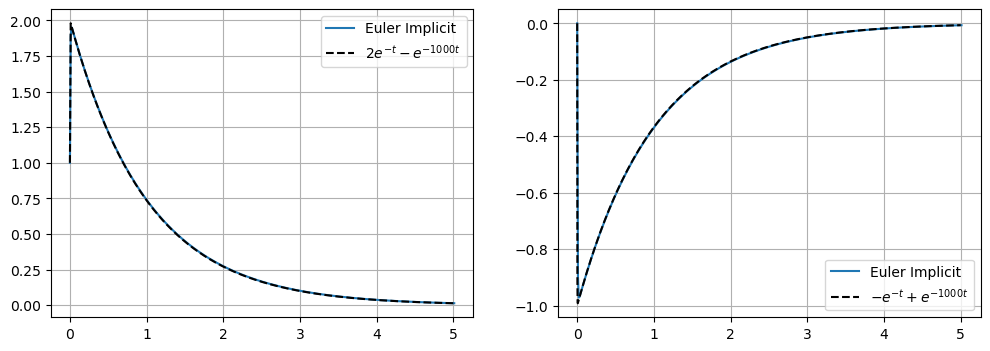

In [569]:
fig, ax = plt.subplots(1,2, figsize=(12,4))

ax[0].plot(tei,yei[0], label = 'Euler Implicit')
ax[0].plot(tei,2*np.exp(-tei)-np.exp(-1000*tei), linestyle='--', c='k', label = r'$2e^{-t}-e^{-1000t}$')

ax[1].plot(tei,yei[1], label = 'Euler Implicit')
ax[1].plot(x,-np.exp(-x)+np.exp(-1000*x), linestyle='--', c='k', label = r'$-e^{-t}+e^{-1000t}$')

#ax[0].set_xlim(0,0.9)
#ax[1].set_xlim(0,0.9)

ax[1].legend()
ax[0].legend()
ax[0].grid()
ax[1].grid()

La soluzione rimane stabile anche per h = 0.1

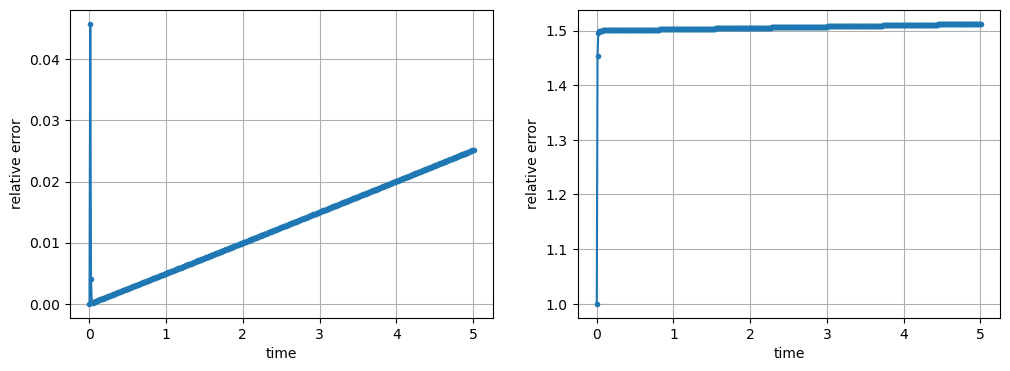

In [575]:
fig, ax = plt.subplots(1,2, figsize=(12,4))

ax[0].plot(tei,abs(yei[0]-(2*np.exp(-tei)-np.exp(-1000*tei)))/(2*np.exp(-tei)-np.exp(-1000*tei)), marker='.')
ax[1].plot(tei,abs(yei[1]-(2*np.exp(-tei)-np.exp(-1000*tei)))/(2*np.exp(-tei)-np.exp(-1000*tei)), marker='.')
ax[0].set_xlabel('time')
ax[0].set_ylabel('relative error')
ax[1].set_xlabel('time')
ax[1].set_ylabel('relative error')
ax[0].grid()
ax[1].grid()

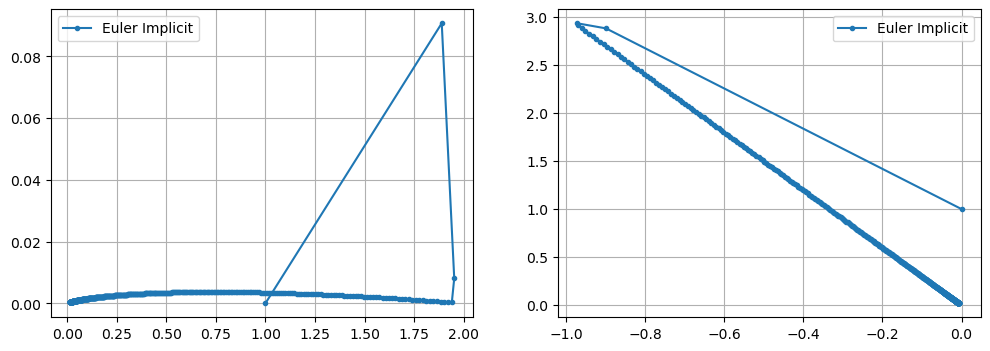

In [505]:
fig, ax = plt.subplots(1,2, figsize=(12,4))

ax[0].plot(yei[0],abs(yei[0]-(2*np.exp(-tei)-np.exp(-1000*tei))), label = 'Euler Implicit', marker='.')
ax[1].plot(yei[1],abs(yei[1]-(2*np.exp(-tei)-np.exp(-1000*tei))), label = 'Euler Implicit', marker='.')

#ax[0].set_xlim(0,0.9)
#ax[1].set_xlim(0,0.9)

ax[1].legend()
ax[0].legend()
ax[0].grid()
ax[1].grid()

## (f): MIDPOINT IMPLICIT

Nel metodo Euler Implicito:


-> Sempre stabile

In [623]:
h = 0.001 #ho problemi con h alti

tmi,ymi = integrate(f_prime,t_span,y0,h,method=midpoint_implicit) #PROBLEMA
np.shape(yee)

(1, 82)

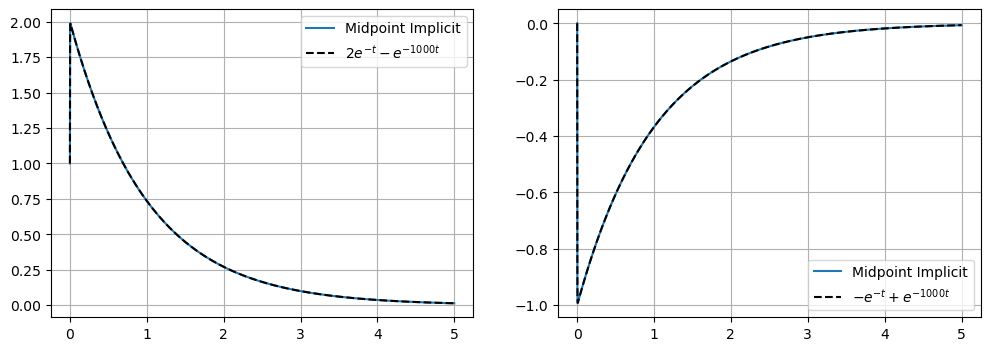

In [624]:
fig, ax = plt.subplots(1,2, figsize=(12,4))

ax[0].plot(tmi,ymi[0], label = 'Midpoint Implicit')
ax[0].plot(tmi,2*np.exp(-tmi)-np.exp(-1000*tmi), linestyle='--', c='k', label = r'$2e^{-t}-e^{-1000t}$')

ax[1].plot(tmi,ymi[1], label = 'Midpoint Implicit')
ax[1].plot(tmi,-np.exp(-tmi)+np.exp(-1000*tmi), linestyle='--', c='k', label = r'$-e^{-t}+e^{-1000t}$')

#ax[0].set_xlim(0,0.9)
#ax[1].set_xlim(0,0.9)

ax[1].legend()
ax[0].legend()
ax[0].grid()
ax[1].grid()

La soluzione rimane stabile anche per h = 0.1

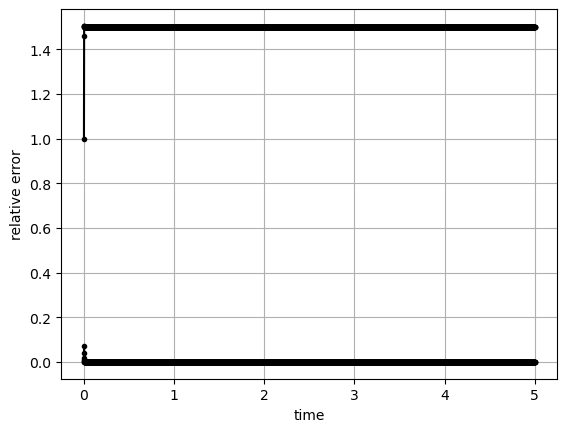

In [621]:
plt.plot(tmi,abs(ymi[0]-(2*np.exp(-tmi)-np.exp(-1000*tmi)))/(2*np.exp(-tmi)-np.exp(-1000*tmi)), color='k', marker='.')
plt.plot(tmi,abs(ymi[1]-(2*np.exp(-tmi)-np.exp(-1000*tmi)))/(2*np.exp(-tmi)-np.exp(-1000*tmi)), color='k', marker='.')
plt.xlabel('time')
plt.ylabel('relative error')
plt.grid()

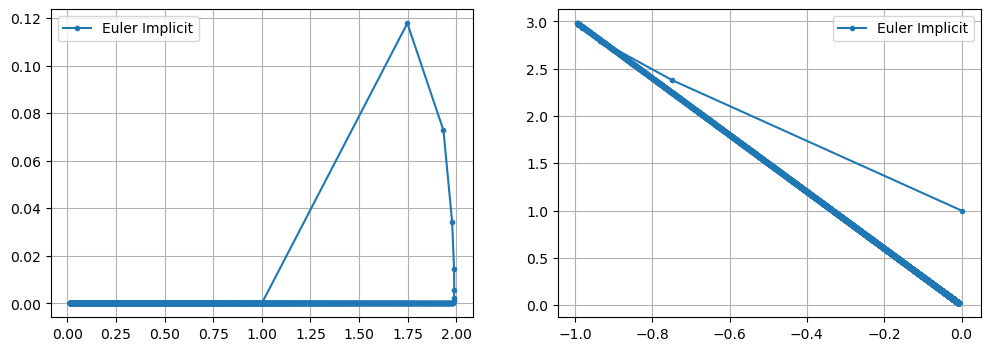

In [622]:
fig, ax = plt.subplots(1,2, figsize=(12,4))

ax[0].plot(ymi[0],abs(ymi[0]-(2*np.exp(-tmi)-np.exp(-1000*tmi))), label = 'Euler Implicit', marker='.')

ax[1].plot(ymi[1],abs(ymi[1]-(2*np.exp(-tmi)-np.exp(-1000*tmi))), label = 'Euler Implicit', marker='.')

#ax[0].set_xlim(0,0.9)
#ax[1].set_xlim(0,0.9)

ax[1].legend()
ax[0].legend()
ax[0].grid()
ax[1].grid()

# Ex. 3

Exercise 3: The Simple Pendulum - Method Comparison
-
The equation of motion for a simple pendulum of length $l$ is

$$
\ddot{\theta}=-\frac{g}{l} \sin \theta
$$


Rewrite as a first-order system with $\omega=\dot{\theta}$ :

$$
\dot{\theta}=\omega, \quad \dot{\omega}=-\frac{g}{l} \sin \theta .
$$


The Hamiltonian is $H=\frac{1}{2} l^2 \omega^2-g l \cos \theta$ (conserved).

Use $g=10, l=1$ and initial conditions $\theta(0)=0.5 \mathrm{rad}, \omega(0)=0$. The exact period for amplitude $\theta_0$ is $T=4 K\left(\sin \left(\theta_0 / 2\right)\right) \cdot \sqrt{l / g}$, where $K^{* *}$ is the complete elliptic integral of the first kind.

** check the specific implementation of the elliptic integral to figure out how the argument needs to be provided.

(a) Implement the following methods and integrate over $N_{\text {orb }}=100$ periods with step size $h=T / 100$ :

(i) Forward Euler
(ii) Explicit midpoint (RK2)
(iii) Classical RK4
(iv) Leapfrog (KDK)

(b) Energy conservation. For each method, plot $\Delta H(t) / H(0)$ (relative energy error) over the full integration.

(i) Which methods show secular (trending) energy drift?
(ii) Which methods show bounded oscillation of the energy error?
(iii) Explain the qualitative difference in terms of symplecticity.

(c) Phase-space portrait. Plot $(\theta, \omega)$ trajectories for all methods. Which orbits remain closed? Which spiral inward or outward?

(d) Convergence study. For each method, integrate over 10 periods with $h=T / N$ for $N=50,100,200,400,800$. Measure the global error at $t=10 T$ (compare $\theta$ with the exact solution obtained from the elliptic-function representation or a very high-accuracy reference integration). Plot $\log$ (error) vs. $\log (h)$ and verify the expected convergence rates (slopes $1,2,4$ for the respective methods).

(e) Cost-accuracy comparison. Plot global error at $t=10 T$ vs. total number of $f$ evaluations (not vs. $h$ ). Which method gives the best accuracy per unit computational cost? Does the answer depend on the target accuracy?

In [893]:
g = 10
l = 1

def omega_prime(omega, theta):
    return -g/l*np.sin(theta)

def theta_prime(omega, theta):
    return omega

def f_prime(t, y,args):
    omega, theta = y
    return np.array([omega_prime(omega,theta), theta_prime(omega,theta)])

In [894]:
def Ep(theta):
    ''' Potential V
    '''
    return -g*l*np.cos(theta)

    
def Ek(omega):
    ''' Kinetic Energy per unit mass T
    '''
    return 0.5*l**2*omega**2

def H(y):
    omega, theta = y
    return Ek(omega) + Ep(theta)

In [895]:
def dV_dtheta(theta):
    return g*l*np.sin(theta)

In [896]:
y0 = np.array([0.,0.5])
K = scipy.special.ellipk(np.sin(0.5/2)**2)
T = 4*K*np.sqrt(l/g)

tf = 100 * T
t_span = (0,tf)

H0 = H(y0)

In [897]:
def theta_true(t,y0):
    omega0, theta0 = y0
    m = np.sin(theta0 / 2)**2
    omega = np.sqrt(g / l)
    u = omega * t + scipy.special.ellipk(m)
    sn = scipy.special.ellipj(u, m)[0]
    theta_exact = 2 * np.arcsin(np.sin(theta0 / 2) * sn)
    return theta_exact
    
def omega_true(t,y0):
    omega0, theta0 = y0
    m = np.sin(theta0 / 2)**2
    omegai = np.sqrt(g / l)
    u = omegai * t + scipy.special.ellipk(m)
    sn, cn, dn, ph = scipy.special.ellipj(u, m)
    omega_exact = 2 * np.sqrt(g/l) * np.sin(theta0 / 2) * cn * dn
    return omega_exact


## (a)

In [898]:
h = T/100

tee,yee = integrate(f_prime,t_span,y0,h,method=euler_explicit)
tme,yme = integrate(f_prime,t_span,y0,h,method=midpoint_explicit)
trk,yrk = integrate(f_prime,t_span,y0,h,method=RK4)
tkdk,ykdk = integrate(f_prime,t_span,y0,h,method=KDK, args=[dV_dtheta,1])

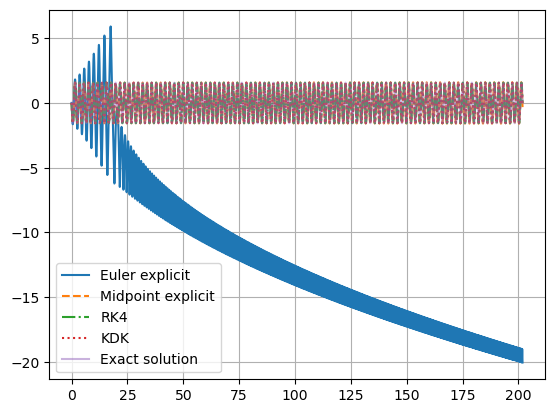

In [899]:
plt.plot(tee,yee[0], label='Euler explicit')
plt.plot(tme,yme[0], label='Midpoint explicit', linestyle='--')
plt.plot(trk,yrk[0], label='RK4', linestyle='-.')
plt.plot(tkdk,ykdk[0], label='KDK', linestyle=':')
plt.plot(tee,omega_true(tee,y0), label='Exact solution', alpha=0.5)

plt.grid()
plt.legend()

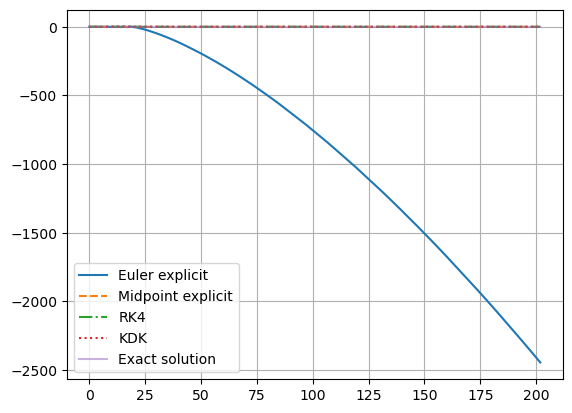

In [900]:
plt.plot(tee,yee[1], label='Euler explicit')
plt.plot(tme,yme[1], label='Midpoint explicit', linestyle='--')
plt.plot(trk,yrk[1], label='RK4', linestyle='-.')
plt.plot(tkdk,ykdk[1], label='KDK', linestyle=':')
plt.plot(tee,theta_true(tee,y0), label='Exact solution', alpha=0.5)

plt.grid()
plt.legend()

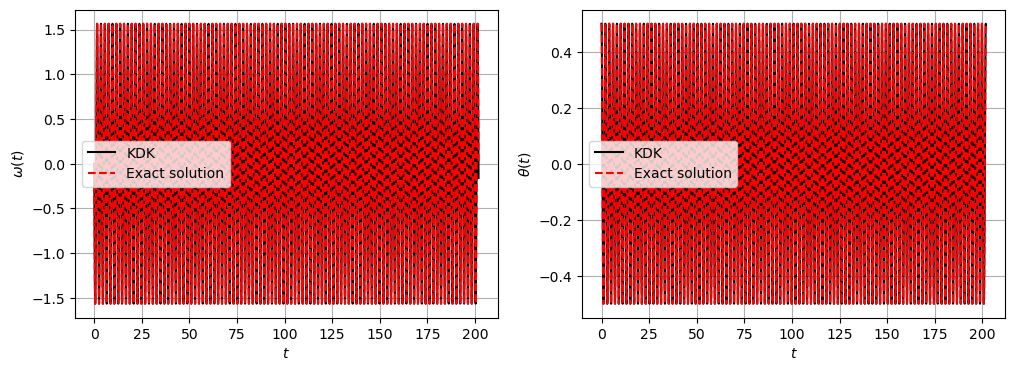

In [901]:
fig, ax = plt.subplots(1,2, figsize=(12,4))

ax[0].plot(tkdk,ykdk[0], label='KDK',c='k')
ax[0].plot(tee, omega_true(tee,y0), label='Exact solution', linestyle='--',c='r')
ax[0].set_ylabel(r'$\omega(t)$')

ax[1].plot(tkdk,ykdk[1], label='KDK',c='k')
ax[1].set_ylabel(r'$\theta(t)$')
ax[1].plot(tee,theta_true(tee,y0), label='Exact solution', linestyle='--',c='r')

for i in [0,1]:
    ax[i].grid()
    ax[i].legend() 
    ax[i].set_xlabel(r'$t$')



## (b)

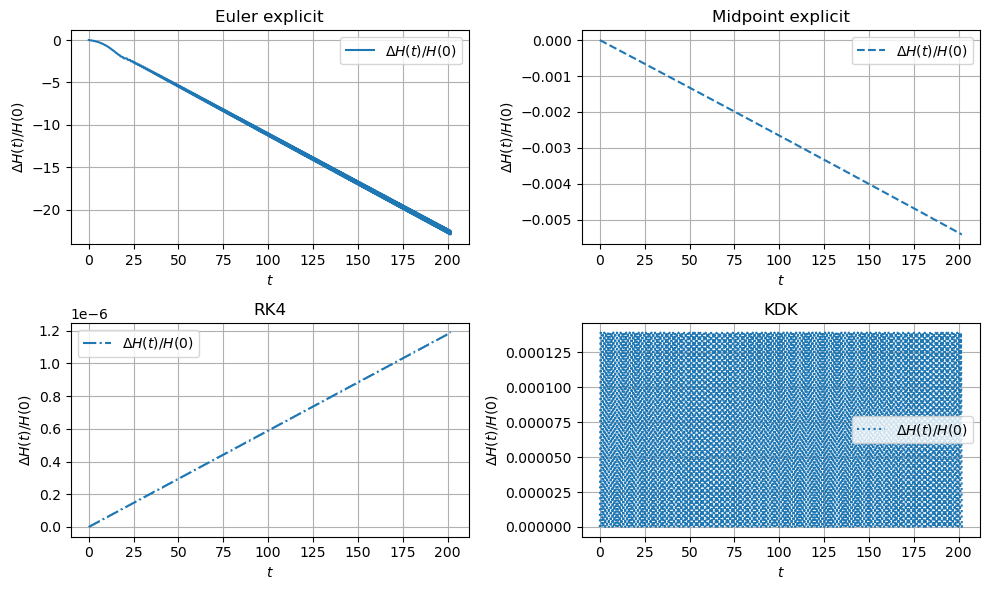

In [902]:
fig, ax = plt.subplots(2,2, figsize=(10,6), layout='tight')


ax[0][0].plot(tee,(H(yee)-H0)/H0, label=r'$\Delta H(t) / H(0)$')
ax[0][0].set_title('Euler explicit')


ax[0][1].plot(tme,(H(yme)-H0)/H0, label=r'$\Delta H(t) / H(0)$', linestyle='--')
ax[0][1].set_title('Midpoint explicit')


ax[1][0].plot(trk,(H(yrk)-H0)/H0, label=r'$\Delta H(t) / H(0)$', linestyle='-.')
ax[1][0].set_title('RK4')


ax[1][1].plot(tkdk,(H(ykdk)-H0)/H0, label=r'$\Delta H(t) / H(0)$', linestyle=':')
ax[1][1].set_title('KDK')


for i in [0,1]:
    for j in [0,1]:
        ax[i][j].set_xlabel(r'$t$')
        ax[i][j].set_ylabel(r'$\Delta H(t) / H(0)$')
        ax[i][j].grid()
        ax[i][j].legend() 


## (c)

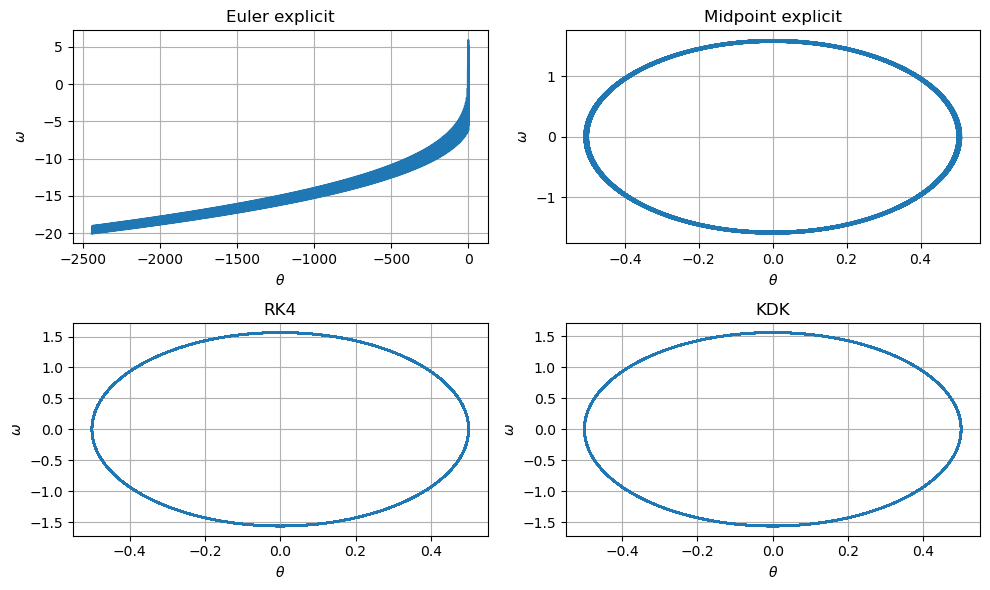

In [903]:
fig, ax = plt.subplots(2,2, figsize=(10,6), layout='tight')


ax[0][0].plot(yee[1],yee[0])
ax[0][0].set_title('Euler explicit')


ax[0][1].plot(yme[1],yme[0])
ax[0][1].set_title('Midpoint explicit')


ax[1][0].plot(yrk[1],yrk[0])
ax[1][0].set_title('RK4')


ax[1][1].plot(ykdk[1],ykdk[0])
ax[1][1].set_title('KDK')


for i in [0,1]:
    for j in [0,1]:
        ax[i][j].set_xlabel(r'$\theta$')
        ax[i][j].set_ylabel(r'$\omega$')
        ax[i][j].grid()

## (d)

In [994]:
Ns = np.array([50,100,200,400,600,800,900])

tf = 10 * T
t_span = (0,tf)

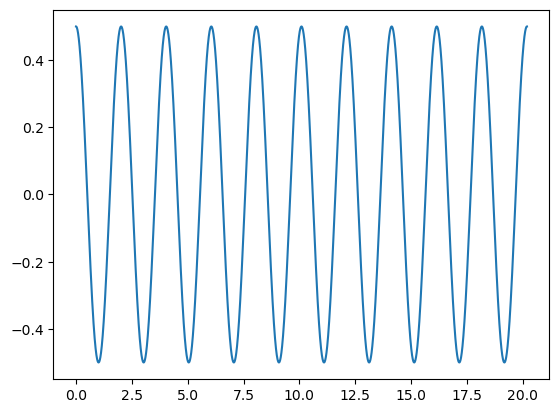

Signature: theta_true(t, y0)
Docstring: <no docstring>
File:      /tmp/ipykernel_60100/910225956.py
Type:      function

In [995]:
plt.plot(tee,theta_true(tee,y0))
theta_true?

In [996]:
hs = T/Ns
err_ee = []
err_me = []
err_rk = []
err_kdk = []

for h in hs:
    tee,yee = integrate(f_prime,t_span,y0,h,method=euler_explicit)
    err_ee = np.append(err_ee, abs((yee[1][int(10*T/h)]-theta_true(tee[int(10*T/h)],y0)))/theta_true(tee[int(10*T/h)],y0))
    
    tme,yme = integrate(f_prime,t_span,y0,h,method=midpoint_explicit)
    err_me = np.append(err_me, abs((yme[1][int(10*T/h)]-theta_true(tme[int(10*T/h)],y0)))/theta_true(tee[int(10*T/h)],y0))
    
    trk,yrk = integrate(f_prime,t_span,y0,h,method=RK4)
    err_rk = np.append(err_rk, abs((yrk[1][int(10*T/h)]-theta_true(trk[int(10*T/h)],y0)))/theta_true(tee[int(10*T/h)],y0))
    
    tkdk,ykdk = integrate(f_prime,t_span,y0,h,method=KDK, args=[dV_dtheta,1])
    err_kdk = np.append(err_kdk, abs((ykdk[1][int(10*T/h)]-theta_true(tkdk[int(10*T/h)],y0)))/theta_true(tee[int(10*T/h)],y0))

In [997]:
hs = T/Ns

err_ee = []
err_me = []
err_rk = []
err_kdk = []

for h in hs:
    ind_T10 = int(10*T/h)
    tee,yee = integrate(f_prime,t_span,y0,h,method=euler_explicit)
    err = abs((theta_true(tee[-1],y0)-yee[1][-1])/theta_true(tee[-1],y0))
    err_ee = np.append(err_ee, err)
    
    tme,yme = integrate(f_prime,t_span,y0,h,method=midpoint_explicit)
    err = abs((theta_true(tme[-1],y0)-yme[1][-1])/theta_true(tme[-1],y0))
    err_me = np.append(err_me, err)
    
    trk,yrk = integrate(f_prime,t_span,y0,h,method=RK4)
    err = abs((theta_true(trk[-1],y0)-yrk[1][-1])/theta_true(trk[-1],y0))
    err_rk = np.append(err_rk,err)
    
    tkdk,ykdk = integrate(f_prime,t_span,y0,h,method=KDK, args=[dV_dtheta,1])
    err = abs((theta_true(tkdk[-1],y0)-ykdk[1][-1])/theta_true(tkdk[-1],y0))
    err_kdk = np.append(err_kdk, err)

In [998]:
def line(x,m,q):
    return m*x+q

In [1014]:
par_ee = scipy.optimize.curve_fit(line, np.log(hs[2:]), np.log(err_ee[2:]))[0]
par_me = scipy.optimize.curve_fit(line, np.log(hs[3:]), np.log(err_me[3:]))[0]
par_rk = scipy.optimize.curve_fit(line, np.log(hs[1:]), np.log(err_rk[1:]))[0]
par_kdk = scipy.optimize.curve_fit(line, np.log(hs[2:]), np.log(err_kdk[2:]))[0]

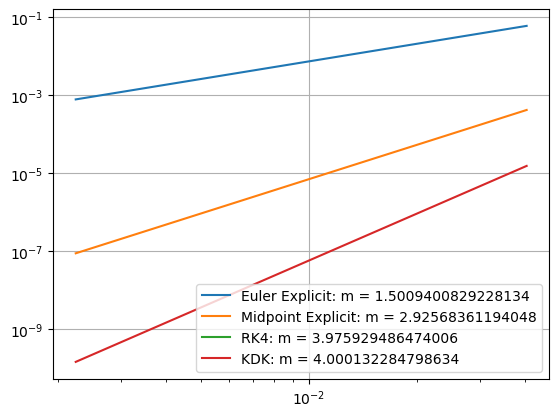

In [1015]:
for par, label in zip([par_ee, par_me, par_rk, par_kdk], ['Euler Explicit', 'Midpoint Explicit', 'RK4', 'KDK']):
    s = label + ': m = ' + str(par[0])
    plt.plot(x,x**par[0]*par[1], label=s)
plt.yscale('log')
plt.xscale('log')
plt.legend()
plt.grid()


# perché mi viene l'errore locale?????????????

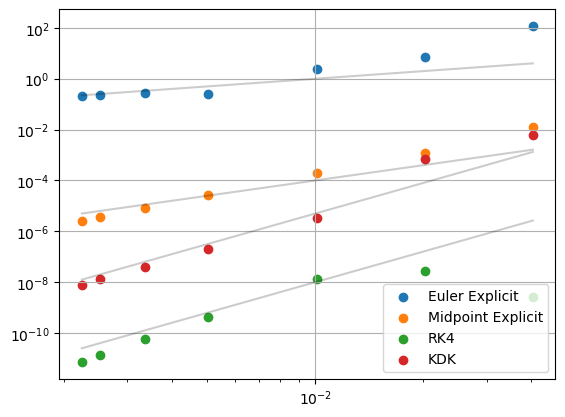

In [1016]:
for err, label in zip([err_ee, err_me, err_rk, err_kdk], ['Euler Explicit', 'Midpoint Explicit', 'RK4', 'KDK']):
    plt.scatter(hs,err,label=label)
x = np.linspace(min(hs),max(hs))
plt.plot(x,x*100,c='k', alpha=0.2)
plt.plot(x,x**2,c='k', alpha=0.2)
plt.plot(x,x**4,c='k', alpha=0.2)
plt.plot(x,x**4*500,c='k', alpha=0.2)


plt.yscale('log')
plt.xscale('log')
plt.legend()
plt.grid()